# Workflow 11 -- Hybrid backbones × 7 classifiers (+ Grad-CAM)
## BRISC 2025 -- audited partition

**Catarina Bota | UCP**

Uses the fine-tuned W3 (plain CNN) and W6..W10 (transfer-learning backbones) as **feature extractors**, and trains the same **7 W3-matched classifiers** on top of each. Everything runs on the audited partition for a direct comparison with the W3 baseline.

**Six feature extractors:**
- **W3** CNN from scratch (128px, /255 preprocessing) -- the coursework baseline
- **W6** ResNet50 (ImageNet)
- **W7** VGG16 (ImageNet)
- **W8** EfficientNetB2 (ImageNet)
- **W9** ConvNeXt-Tiny (ImageNet)
- **W10** ResNet50 (**RadImageNet**, medical pretraining) -- the "domain-specific pretraining" argument

**Seven classifiers per backbone** (identical W3 hyperparameters, seed=42, StandardScaler): XGBoost · LightGBM · RandomForest · GradientBoosting · CatBoost · SVM(RBF) · MLP.

Total: 6 × 7 = **42 hybrid combinations**, plus Grad-CAM++ heatmaps side-by-side for a visual explanation of what each pretraining attends to on identical inputs.

> **Architecture note.** Just like `workflow6_10_backbones_leakage.ipynb`, this notebook is a **pure orchestrator** -- it does NOT import TensorFlow. All GPU-bound work happens in isolated subprocesses (`train_w11_hybrid.py`, `w11_gradcam.py`) so VRAM is fully released between backbones. Classifier training runs inside the training worker (CPU-only) and its outputs are read back as CSV / pickles.

## 1. Orchestration setup

In [1]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print('Python:', sys.executable)
print('This kernel deliberately does NOT import tensorflow.')

Python: /root/brisc/.venv/bin/python3
This kernel deliberately does NOT import tensorflow.


## 2. Configuration

In [2]:
PROJECT_DIR = '/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui'
AUD_BASE    = '/root/brisc/data/brisc2025_clean/classification_task'
OUT_ROOT    = f'{PROJECT_DIR}/w11_hybrid'
os.makedirs(OUT_ROOT, exist_ok=True)

WORKER_TRAIN     = f'{PROJECT_DIR}/train_w11_hybrid.py'
WORKER_GRADCAM   = f'{PROJECT_DIR}/w11_gradcam.py'
WORKER_RETRAIN_W2 = f'{PROJECT_DIR}/retrain_w2_cnn_v3.py'
WORKER_RETRAIN_W9 = f'{PROJECT_DIR}/retrain_w9_keras.py'

# Prerequisite markers. The W2 CNN is retrained in-place over modelo_brisc.h5
# (v3 protocol); its meta json is the completion marker. W9 ConvNeXt is the ONE
# model that must be .keras (Keras 3 cannot round-trip ConvNeXt through .h5).
W2_META_MARKER   = f'{PROJECT_DIR}/modelo_brisc_v3_meta.json'
W9_MODEL_KERAS   = f'{PROJECT_DIR}/leakage_backbones/W9_ConvNeXtTiny_ImageNet/audited/model.keras'

BACKBONES = [
    'W3_CNN_scratch',
    'W6_ResNet50_ImageNet',
    'W7_VGG16_ImageNet',
    'W8_EfficientNetB2_ImageNet',
    'W9_ConvNeXtTiny_ImageNet',
    'W10_RadImageNet_ResNet50',
]

for w in (WORKER_TRAIN, WORKER_GRADCAM, WORKER_RETRAIN_W2, WORKER_RETRAIN_W9):
    assert os.path.exists(w), f'Missing worker script: {w}'
print('Backbones     :', BACKBONES)
print('Output root   :', OUT_ROOT)
print('Training worker :', WORKER_TRAIN)
print('Grad-CAM worker :', WORKER_GRADCAM)

Backbones     : ['W3_CNN_scratch', 'W6_ResNet50_ImageNet', 'W7_VGG16_ImageNet', 'W8_EfficientNetB2_ImageNet', 'W9_ConvNeXtTiny_ImageNet', 'W10_RadImageNet_ResNet50']
Output root   : /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/w11_hybrid
Training worker : /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/train_w11_hybrid.py
Grad-CAM worker : /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/w11_gradcam.py


## 3. Prerequisites -- corrected W2 CNN and .keras W9 model

Two pretrained artefacts are re-generated on demand if missing:

1. **`modelo_brisc_v3.keras`** -- the W2 scratch CNN retrained with the corrected `workflow2_leakage_v3` protocol (deterministic dataframe shuffle, `val_gen shuffle=False`, seed=42). Reaches ~93% audited test accuracy (vs ~88% for the legacy `modelo_brisc.h5`, which is kept only for the PyQt6 GUI and the original W3 notebook). Used as the `W3_CNN_scratch` feature extractor.
2. **`leakage_backbones/W9_ConvNeXtTiny_ImageNet/audited/model.keras`** -- W9 retrained and saved in the `.keras` native format because Keras 3 cannot deserialise ConvNeXt from `.h5` (LayerScale + positional-arg bugs). Same seed and protocol as the original W9 run.

Each cell below only re-runs if its target file is missing, so re-executing this notebook top-to-bottom after the first successful run is a no-op for these steps.

In [3]:
# Prerequisite 1 -- canonical W2 scratch CNN retrained in-place (v3 protocol).
# The meta json is written only on a successful retrain, so it is the marker.
if os.path.exists(W2_META_MARKER):
    print(f'  [skip] W2 CNN (v3) already retrained -- {W2_META_MARKER} present')
else:
    print('#' * 70); print('# RETRAIN  W2 scratch CNN (v3 protocol -> modelo_brisc.h5)')
    print('#' * 70, flush=True)
    subprocess.run([sys.executable, WORKER_RETRAIN_W2], check=True)
    # The W3 hybrid features cached from the OLD CNN are now stale -- purge them
    # so section 4 re-extracts from the freshly retrained model.
    import shutil
    stale = f'{OUT_ROOT}/W3_CNN_scratch'
    if os.path.exists(stale):
        shutil.rmtree(stale); print(f'  purged stale features cache: {stale}')

# Prerequisite 2 -- ConvNeXt-Tiny W9 in .keras format (the single .h5 exception)
if os.path.exists(W9_MODEL_KERAS):
    print(f'  [skip] W9 .keras already exists at {W9_MODEL_KERAS}')
else:
    print('#' * 70); print('# RETRAIN  W9 ConvNeXt-Tiny (saving .keras)')
    print('#' * 70, flush=True)
    subprocess.run([sys.executable, WORKER_RETRAIN_W9], check=True)

  [skip] W2 CNN (v3) already retrained -- /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/modelo_brisc_v3_meta.json present
  [skip] W9 .keras already exists at /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_backbones/W9_ConvNeXtTiny_ImageNet/audited/model.keras


## 4. Feature extraction + 7 classifiers per backbone

For each backbone, a subprocess runs `train_w11_hybrid.py` which:
1. Loads the pretrained `model.h5`
2. Extracts 128-d features from the `feat_dense` layer (or `layers[:-1]` for the plain W3 CNN)
3. Applies `StandardScaler` fit-on-train
4. Trains the 7 W3-matched classifiers
5. Saves features + scaler + trained classifiers + comparison table

Skip if already done (features are cached in `<out>/features.npz` and `comparison.csv` exists).

In [4]:
for backbone in BACKBONES:
    comp = f'{OUT_ROOT}/{backbone}/comparison.csv'
    if os.path.exists(comp):
        print(f'  [skip] {backbone} -- comparison.csv already exists')
        continue
    print('\n' + '#' * 70)
    print(f'# TRAIN  {backbone}')
    print('#' * 70, flush=True)
    subprocess.run([sys.executable, WORKER_TRAIN, backbone, AUD_BASE, OUT_ROOT],
                   check=True)

  [skip] W3_CNN_scratch -- comparison.csv already exists
  [skip] W6_ResNet50_ImageNet -- comparison.csv already exists
  [skip] W7_VGG16_ImageNet -- comparison.csv already exists
  [skip] W8_EfficientNetB2_ImageNet -- comparison.csv already exists
  [skip] W9_ConvNeXtTiny_ImageNet -- comparison.csv already exists
  [skip] W10_RadImageNet_ResNet50 -- comparison.csv already exists


## 5. Aggregate all comparison tables

In [5]:
rows = []
for backbone in BACKBONES:
    p = f'{OUT_ROOT}/{backbone}/comparison.csv'
    if not os.path.exists(p):
        print(f'  missing {p}'); continue
    df = pd.read_csv(p); df.insert(0, 'backbone', backbone)
    rows.append(df)
big = pd.concat(rows, ignore_index=True)
big.to_csv(f'{OUT_ROOT}/all_hybrid_results.csv', index=False)
print(f'Saved {OUT_ROOT}/all_hybrid_results.csv  ({len(big)} rows)')
big

Saved /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/w11_hybrid/all_hybrid_results.csv  (42 rows)


,backbone,classifier,accuracy,precision,recall,f1,auc,ci95_lo,ci95_hi,train_time_s
0,W3_CNN_scratch,LightGBM,96.76,96.75,96.83,96.77,99.77,95.43,97.94,2.91
1,W3_CNN_scratch,SVM (RBF),96.61,96.58,96.67,96.61,99.65,95.28,97.94,0.36
2,W3_CNN_scratch,XGBoost,96.17,96.19,96.24,96.18,99.74,94.69,97.49,13.20
3,W3_CNN_scratch,MLP,96.02,96.15,96.03,96.04,99.72,94.40,97.49,1.45
4,W3_CNN_scratch,CatBoost,95.72,95.78,95.85,95.79,99.69,25.21,26.37,7.66
5,W3_CNN_scratch,GradientBoosting,95.72,95.72,95.85,95.76,99.70,94.25,97.20,42.97
6,W3_CNN_scratch,RandomForest,95.58,95.54,95.82,95.64,99.71,93.95,97.05,1.58
7,W6_ResNet50_ImageNet,SVM (RBF),97.49,97.50,97.67,97.57,99.84,96.31,98.53,0.17
8,W6_ResNet50_ImageNet,MLP,96.90,96.96,97.16,97.02,99.74,95.43,98.08,0.77
9,W6_ResNet50_ImageNet,LightGBM,96.46,96.49,96.74,96.57,99.73,94.99,97.79,2.38


In [6]:
# Best classifier per backbone
idx  = big.groupby('backbone')['accuracy'].idxmax()
best = big.loc[idx, ['backbone', 'classifier', 'accuracy', 'f1', 'auc',
                     'ci95_lo', 'ci95_hi', 'train_time_s']] \
        .sort_values('accuracy', ascending=False).reset_index(drop=True)
best.to_csv(f'{OUT_ROOT}/best_per_backbone.csv', index=False)
best

,backbone,classifier,accuracy,f1,auc,ci95_lo,ci95_hi,train_time_s
0,W7_VGG16_ImageNet,LightGBM,98.67,98.69,99.83,97.64,99.41,3.02
1,W6_ResNet50_ImageNet,SVM (RBF),97.49,97.57,99.84,96.31,98.53,0.17
2,W3_CNN_scratch,LightGBM,96.76,96.77,99.77,95.43,97.94,2.91
3,W9_ConvNeXtTiny_ImageNet,SVM (RBF),96.46,96.55,99.64,94.99,97.79,0.31
4,W8_EfficientNetB2_ImageNet,SVM (RBF),94.84,94.99,99.31,93.22,96.46,0.68
5,W10_RadImageNet_ResNet50,LightGBM,82.01,82.31,95.41,78.91,84.66,3.90


In [7]:
# Compare against the softmax baseline (from W6-W10 direct training +
# W3 CNN test accuracy for reference).
softmax_baseline = {
    'W3_CNN_scratch':             94.54,
    'W6_ResNet50_ImageNet':       97.49,
    'W7_VGG16_ImageNet':          97.94,
    'W8_EfficientNetB2_ImageNet': 93.95,
    'W9_ConvNeXtTiny_ImageNet':   94.99,
    'W10_RadImageNet_ResNet50':   72.12,
}
best_lookup = dict(zip(best['backbone'], best['accuracy']))
delta = []
for b in BACKBONES:
    delta.append({
        'backbone':          b,
        'softmax_acc':       softmax_baseline[b],
        'hybrid_best_acc':   best_lookup.get(b, np.nan),
        'hybrid_best_clf':   best.set_index('backbone').loc[b, 'classifier']
                             if b in best_lookup else None,
        'delta_pp':          round(best_lookup.get(b, np.nan) - softmax_baseline[b], 2)
                             if b in best_lookup else np.nan,
    })
delta_df = pd.DataFrame(delta)
delta_df.to_csv(f'{OUT_ROOT}/softmax_vs_hybrid.csv', index=False)
delta_df

,backbone,softmax_acc,hybrid_best_acc,hybrid_best_clf,delta_pp
0,W3_CNN_scratch,94.54,96.76,LightGBM,2.22
1,W6_ResNet50_ImageNet,97.49,97.49,SVM (RBF),0.00
2,W7_VGG16_ImageNet,97.94,98.67,LightGBM,0.73
3,W8_EfficientNetB2_ImageNet,93.95,94.84,SVM (RBF),0.89
4,W9_ConvNeXtTiny_ImageNet,94.99,96.46,SVM (RBF),1.47
5,W10_RadImageNet_ResNet50,72.12,82.01,LightGBM,9.89


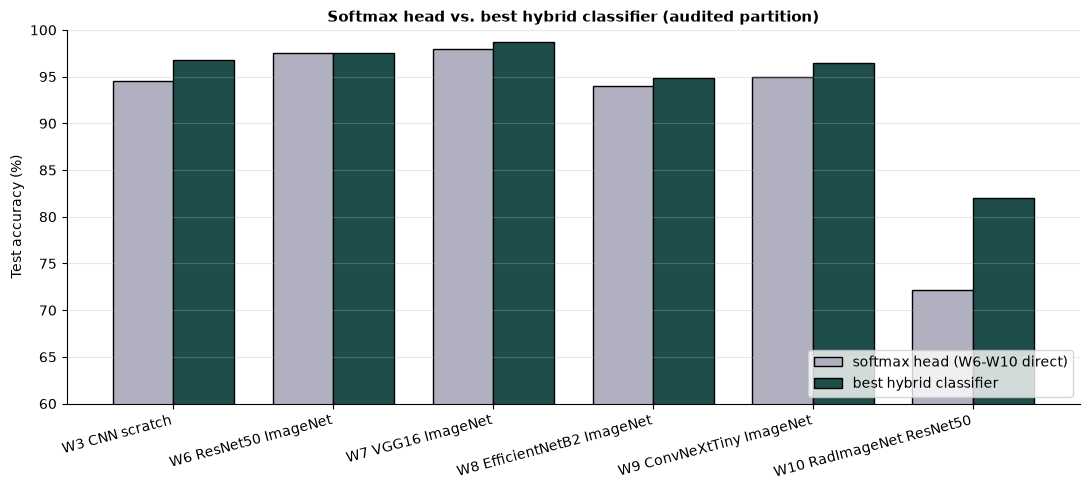

In [8]:
# Bar chart: softmax vs best hybrid, per backbone.
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(BACKBONES)); w = 0.38
ax.bar(x - w/2, delta_df['softmax_acc'],     w, label='softmax head (W6-W10 direct)',
       color='#B0B0C0', edgecolor='black')
ax.bar(x + w/2, delta_df['hybrid_best_acc'], w, label='best hybrid classifier',
       color='#1F4E4A', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels([b.replace('_', ' ') for b in BACKBONES], rotation=15, ha='right')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Softmax head vs. best hybrid classifier (audited partition)',
             fontsize=11, fontweight='bold')
ax.set_ylim([60, 100]); ax.legend(loc='lower right')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_ROOT}/softmax_vs_hybrid.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{OUT_ROOT}/softmax_vs_hybrid.pdf', bbox_inches='tight')
plt.show()

## 6. Grad-CAM++ per backbone

Runs `w11_gradcam.py` in a subprocess per backbone. Each backbone produces 4 heatmaps (one per class) on the **same 4 example images** (first alphabetically in each `test/<class>/`), so the resulting grid is a fair side-by-side visual comparison of what each pretraining attends to.

In [9]:
for backbone in BACKBONES:
    outdir = f'{OUT_ROOT}/{backbone}/gradcam'
    if os.path.exists(f'{outdir}/pituitary.png'):
        print(f'  [skip] {backbone} -- gradcam already generated')
        continue
    print()
    print('#' * 70)
    print(f'# GRADCAM  {backbone}')
    print('#' * 70, flush=True)
    # Non-fatal: a Grad-CAM failure for one backbone must not abort the run.
    proc = subprocess.run([sys.executable, WORKER_GRADCAM, backbone, AUD_BASE, OUT_ROOT])
    if proc.returncode != 0:
        print(f'  [WARN] Grad-CAM failed for {backbone} (exit {proc.returncode}); continuing.')


  [skip] W3_CNN_scratch -- gradcam already generated
  [skip] W6_ResNet50_ImageNet -- gradcam already generated
  [skip] W7_VGG16_ImageNet -- gradcam already generated
  [skip] W8_EfficientNetB2_ImageNet -- gradcam already generated
  [skip] W9_ConvNeXtTiny_ImageNet -- gradcam already generated
  [skip] W10_RadImageNet_ResNet50 -- gradcam already generated


## 7. Composite Grad-CAM figure (6 backbones × 4 classes)

Loads the per-backbone overlays and assembles them into a single figure that goes into the paper.

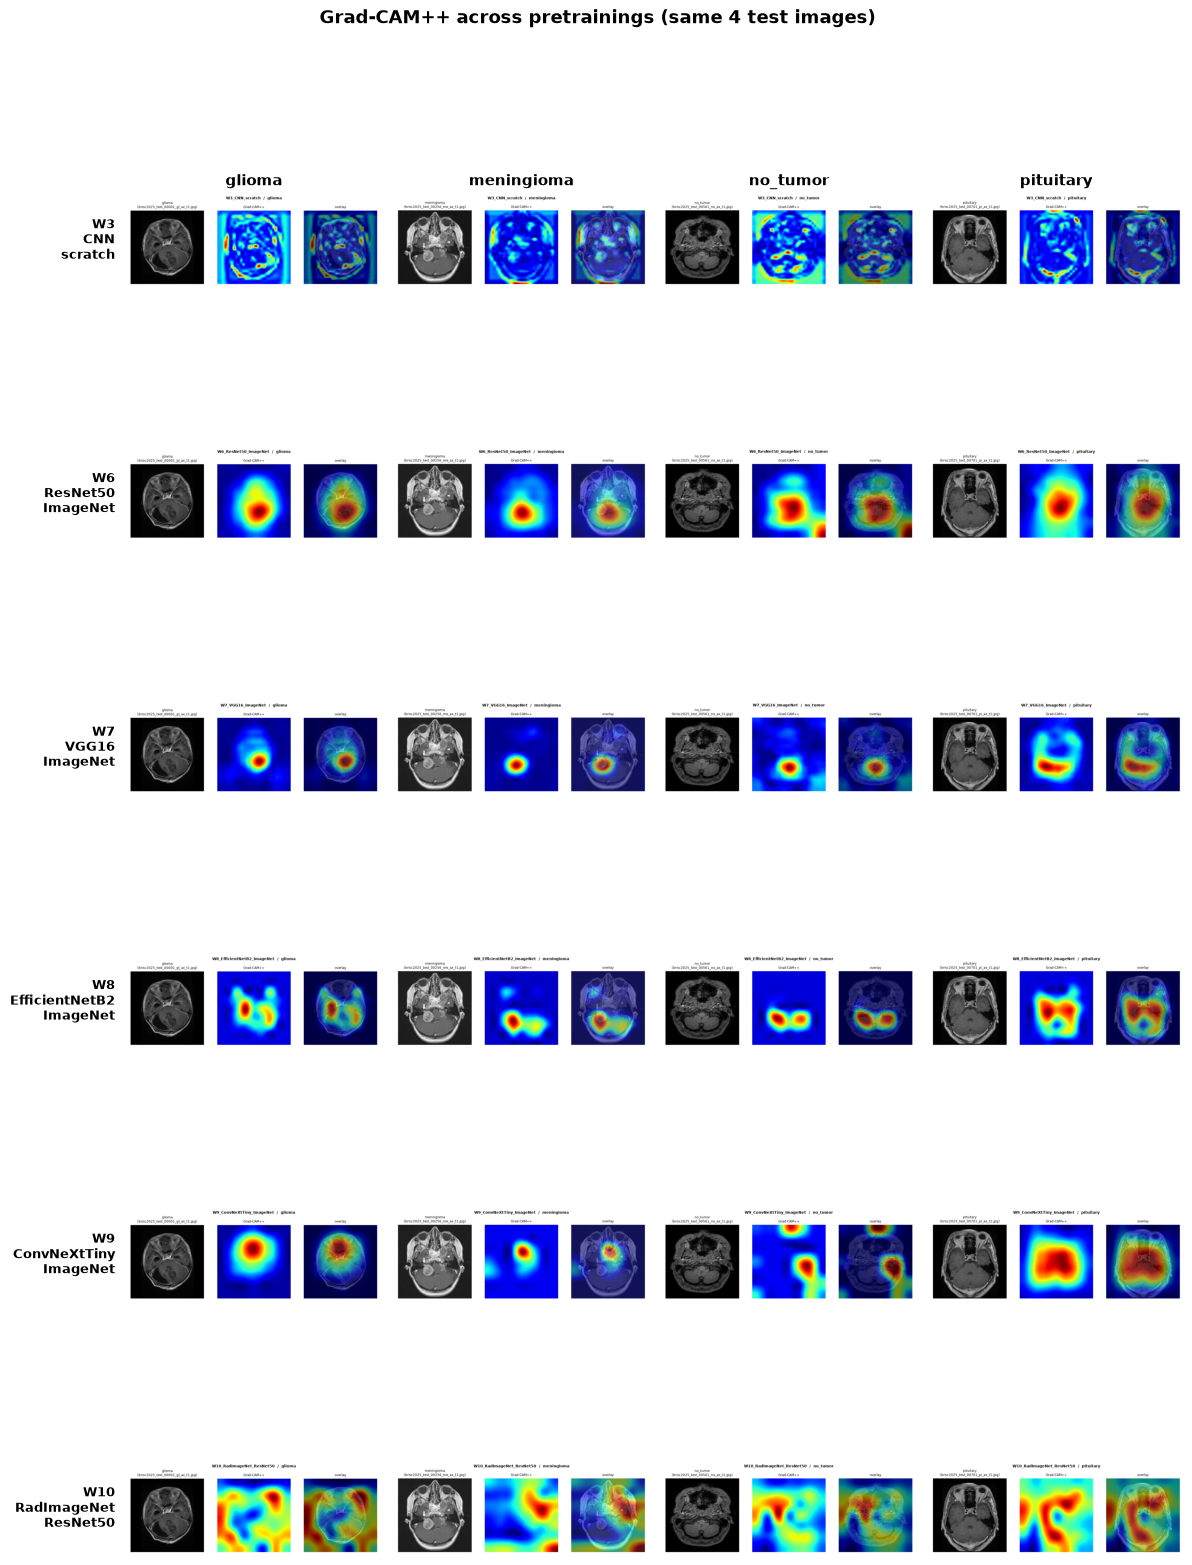

In [10]:
CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

fig, axes = plt.subplots(len(BACKBONES), len(CLASSES),
                          figsize=(3.0 * len(CLASSES), 2.8 * len(BACKBONES)))
for i, backbone in enumerate(BACKBONES):
    for j, cls in enumerate(CLASSES):
        ax = axes[i, j]
        img_path = f'{OUT_ROOT}/{backbone}/gradcam/{cls}.png'
        if os.path.exists(img_path):
            ax.imshow(Image.open(img_path)); ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'missing', ha='center', va='center'); ax.axis('off')
        if i == 0:
            ax.set_title(cls, fontsize=11, fontweight='bold')
        if j == 0:
            ax.text(-0.05, 0.5, backbone.replace('_', '\n'),
                    transform=ax.transAxes, ha='right', va='center',
                    fontsize=9, fontweight='bold')
plt.suptitle('Grad-CAM++ across pretrainings (same 4 test images)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(f'{OUT_ROOT}/gradcam_comparison.png', dpi=140, bbox_inches='tight')
plt.savefig(f'{OUT_ROOT}/gradcam_comparison.pdf', bbox_inches='tight')
plt.show()

## Notes

- **Output layout** per backbone: `features.npz`, `scaler.pkl`, `classifiers/<name>.pkl`, `comparison.csv`, `predictions_best.csv`, `confusion_matrix_best.csv`, `perclass_best.csv`, `best.json`, `gradcam/<class>.png`.
- **Consistency with W3**: the classifier hyperparameters here are copied literally from `workflow3_hybrid_all_classifiers.ipynb` cell 12; the standardisation, seed and feature-layer choice (`feat_dense`, 128-d) match. Including **W3** as a "backbone" makes W3 a direct row in the same table so the transfer-learning gain is visible per-classifier.
- **What to look for**:
  - **Δ softmax → hybrid** per backbone. Small Δ (0-1 pp) on already-high backbones (W7 VGG16 in 98%) is expected (diminishing returns). Larger Δ on the RadImageNet (W10) would suggest the softmax head was under-using the features -- publishable either way.
  - **Grad-CAM localisation** on the same images. Ideally the ImageNet backbones concentrate on the tumour; RadImageNet may show a more diffuse pattern, visually corroborating the ~25 pp gap in raw accuracy.
- **Next**: run `workflow12_shap_comparison.ipynb` for the SHAP analysis across the 42 (backbone, classifier) pairs.